<a href="https://colab.research.google.com/github/Wejdan999/T55/blob/main/Copy_of_Time_Series_Forecasting_Practice_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting Practice Exercise

In this practice exercise, you will work on a time series forecasting task. The goal is to go through the entire workflow from loading the data to evaluating the model and making predictions. Follow each step carefully. The dataset is stored in the `Datasets` file with the name `Aquifer_Petrignano` the target is to predict `Depth_to_Groundwater_P24` column.

## Dataset: Aquifer Petrignano

### Dataset Overview:

- **Name**: Aquifer Petrignano
- **Description**: This dataset contains time series data related to groundwater levels, rainfall, temperature, and hydrometry in the Aquifer Petrignano region. The data is collected over multiple years, capturing various environmental measurements. It is particularly useful for modeling groundwater levels, climate analysis, and time series forecasting.
- **Time Period**: Starting from 14/03/2006
- **Frequency**: Daily observations

### Features:

1. **Date**: The date of the observation in `DD/MM/YYYY` format.
2. **Rainfall_Bastia_Umbra**: Daily rainfall measurement in the Bastia Umbra region (mm).
3. **Depth_to_Groundwater_P24**: Depth to groundwater at observation point P24 (meters).
4. **Depth_to_Groundwater_P25**: Depth to groundwater at observation point P25 (meters).
5. **Temperature_Bastia_Umbra**: Daily temperature in the Bastia Umbra region (°C).
6. **Temperature_Petrignano**: Daily temperature in the Petrignano region (°C).
7. **Volume_C10_Petrignano**: Water volume measured at station C10 in Petrignano (m³).
8. **Hydrometry_Fiume_Chiascio_Petrignano**: Hydrometry measurements of the Fiume Chiascio river in Petrignano (m).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,GRU,SimpleRNN
from sklearn.metrics import mean_squared_error
import math


In [3]:
random.seed(2000)

## Load the Data

Load the time series dataset into a pandas DataFrame.

**Instructions:**
- Use `pandas` to load your dataset.
- Display the first few rows to understand its structure.
- Make sure the datetime column is correctly parsed.

In [4]:
ap=pd.read_csv('/content/drive/MyDrive/T5/Aquifer_Petrignano.csv')

In [5]:
ap.head()

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,28/07/2009,0.0,-28.90,-28.12,27.4,25.6,-34833.888,1.9
1,21/06/2015,0.0,-20.79,-20.45,20.8,0.0,-18681.408,0.0
2,10/10/2019,0.0,-27.36,-26.75,20.3,20.0,-28288.224,2.3
3,09/12/2011,0.0,-27.78,-26.98,9.2,8.8,-37215.072,2.0
4,20/09/2011,1.0,-26.09,-25.55,15.7,15.7,-30856.896,2.0


In [6]:
ap['Date']= pd.to_datetime(ap['Date'])
ap=ap.set_index('Date')

<ipython-input-6-c6eb37c98527>:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ap['Date']= pd.to_datetime(ap['Date'])


## Exploratory Data Analysis (EDA)

Perform exploratory data analysis on the dataset.

**Instructions:**
- Plot the time series data.
- Analyze trends, seasonality, and potential outliers.
- Plot boxplots or scatter plots to identify any outliers or anomalies in the data.
- Seasonal Decomposition: Use seasonal_decompose from the statsmodels library to break down the time series data into trend, seasonality, and residual components. Analyze each component to gain insights into the long-term movement (trend), regular patterns (seasonality), and remaining fluctuations (residuals).

Do more if needed!

<Axes: xlabel='Depth_to_Groundwater_P24', ylabel='Count'>

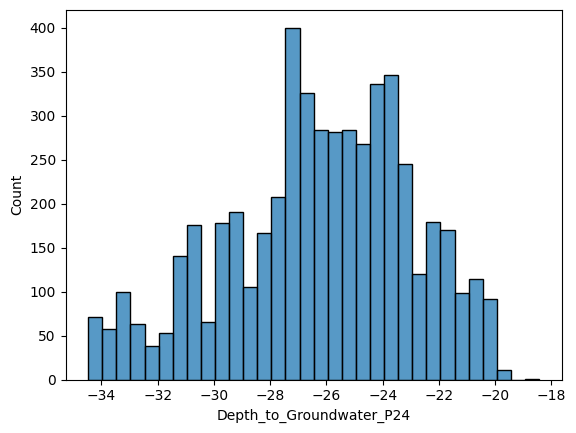

In [7]:
sns.histplot(ap['Depth_to_Groundwater_P24'])

<Axes: >

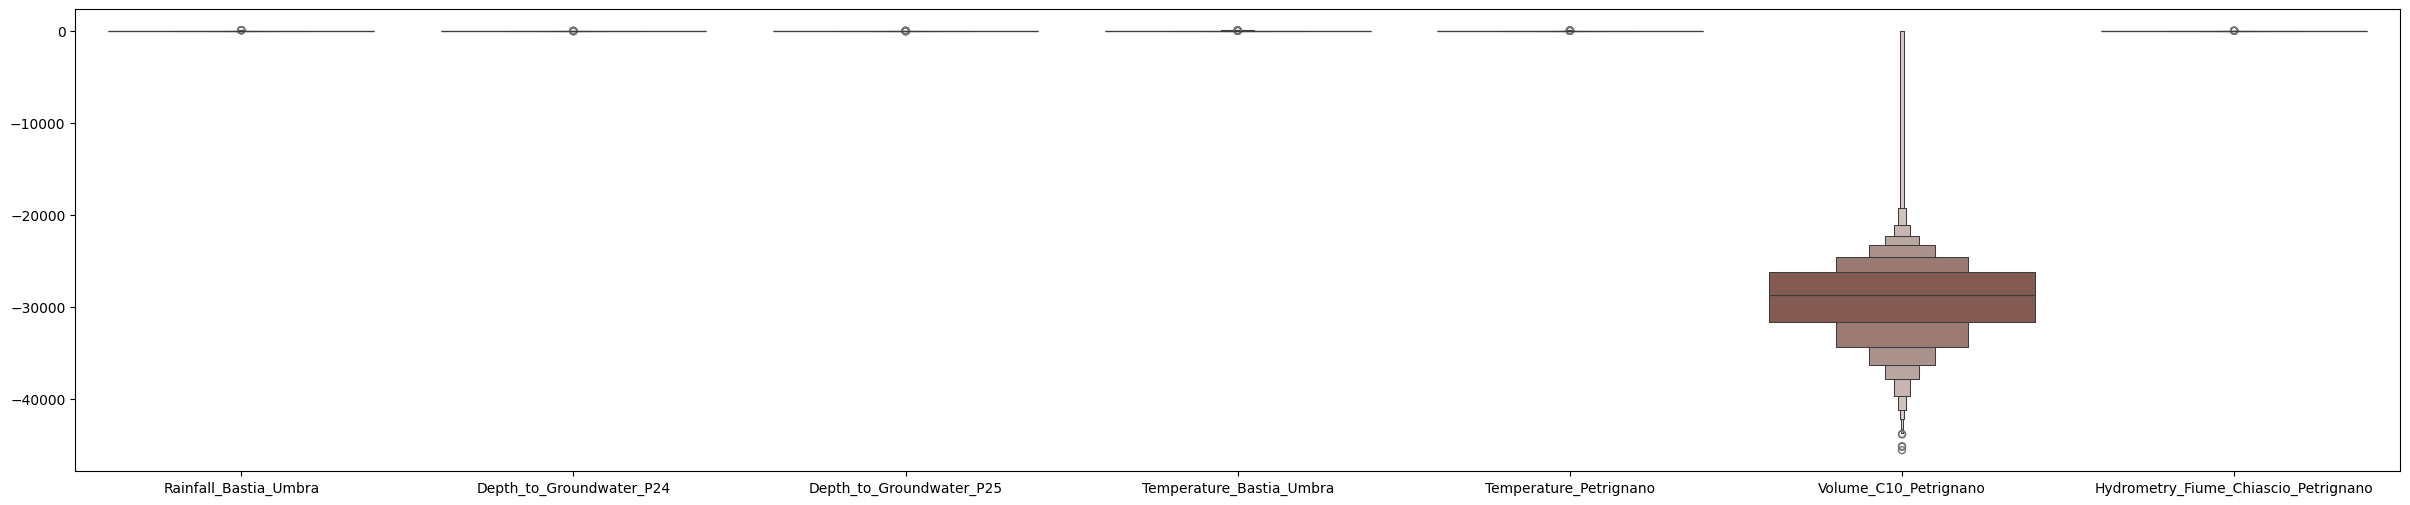

In [8]:
plt.figure(figsize=(30,6))
sns.boxenplot(ap)

In [9]:
Q1= ap['Volume_C10_Petrignano'].quantile(0.25)
Q3=ap['Volume_C10_Petrignano'].quantile(0.75)
IQR = Q3-Q1
lower_bound= Q1 - 0.5* IQR
upper_bound= Q3 + 1.5 * IQR
ap = ap[(ap['Volume_C10_Petrignano'] >= lower_bound ) & (ap['Volume_C10_Petrignano']<= upper_bound)]



<Axes: >

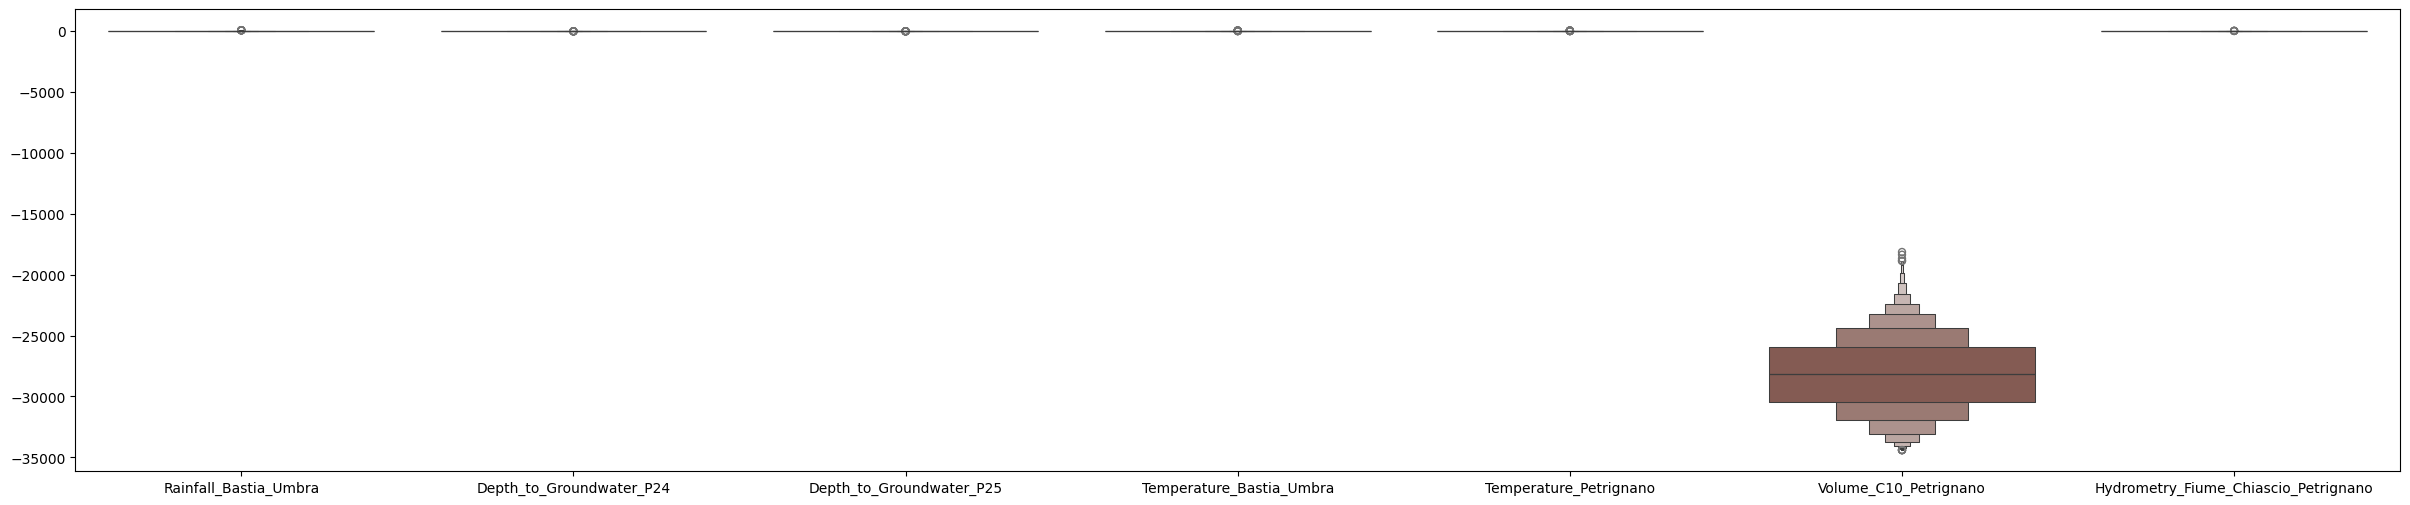

In [10]:
plt.figure(figsize=(30,6))
sns.boxenplot(ap)

## Data Preprocessing

Clean and preprocess the data.

**Instructions:**
- Handle any missing values in the dataset.
- If necessary, resample the data to ensure consistent time intervals.
- Create any additional features needed, such as lags or moving averages.
- Make sure that the dates are sorted correctly.

Do more if needed!

In [11]:
ap.isna().sum()

,0
Rainfall_Bastia_Umbra,619
Depth_to_Groundwater_P24,45
Depth_to_Groundwater_P25,32
Temperature_Bastia_Umbra,619
Temperature_Petrignano,619
Volume_C10_Petrignano,0
Hydrometry_Fiume_Chiascio_Petrignano,619


In [12]:
null_data=pd.isna(ap['Depth_to_Groundwater_P24'])
ap[null_data]

,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
Date,,,,,,,
2019-03-23,0.0,NaN,NaN,13.5,14.5,-25994.304,2.4
2019-03-18,0.4,NaN,NaN,12.4,12.1,-23875.776,2.5
2008-05-27,NaN,NaN,-30.05,NaN,NaN,-32406.048,NaN
2020-03-31,0.4,NaN,NaN,7.3,6.8,-23040.288,2.7
2013-03-25,0.8,NaN,-26.00,9.5,8.5,-29250.720,2.7
2013-03-15,0.0,NaN,-26.67,4.4,4.0,-31741.632,2.9
2008-05-21,NaN,NaN,NaN,NaN,NaN,-25265.952,NaN
2013-03-30,0.0,NaN,-25.79,13.7,12.8,-33429.024,2.6
2019-03-24,0.0,NaN,NaN,13.9,13.6,-26041.824,2.4


In [13]:
ap['Depth_to_Groundwater_P24']=ap['Depth_to_Groundwater_P24'].bfill().ffill()

In [14]:
ap=ap.fillna(ap.mean())

In [15]:
ap.isna().sum()

,0
Rainfall_Bastia_Umbra,0
Depth_to_Groundwater_P24,0
Depth_to_Groundwater_P25,0
Temperature_Bastia_Umbra,0
Temperature_Petrignano,0
Volume_C10_Petrignano,0
Hydrometry_Fiume_Chiascio_Petrignano,0


In [16]:
ap.duplicated().sum()

0

In [17]:
ap.resample('Q').mean()

,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
Date,,,,,,,
2006-09-30,1.693156,-24.787500,-24.200000,14.846951,13.471451,-29514.240000,2.409028
2006-12-31,1.693156,-25.822340,-25.198723,14.846951,13.471451,-31922.649191,2.409028
2007-03-31,1.693156,-27.263214,-26.397321,14.846951,13.471451,-29721.337714,2.409028
2007-06-30,1.693156,-26.829375,-26.051184,14.846951,13.471451,-29818.233000,2.409028
2007-09-30,1.693156,-30.208364,-29.249636,14.846951,13.471451,-31338.976582,2.409028
2007-12-31,1.693156,-30.785326,-30.051802,14.846951,13.471451,-27022.107130,2.409028
2008-03-31,1.693156,-31.229762,-30.587500,14.846951,13.471451,-28991.427429,2.409028
2008-06-30,1.693156,-30.469111,-29.706197,14.846951,13.471451,-26545.708800,2.409028
2008-09-30,1.693156,-32.167164,-31.447015,14.846951,13.471451,-30105.293373,2.409028


In [18]:
ap.sort_index(inplace=True)

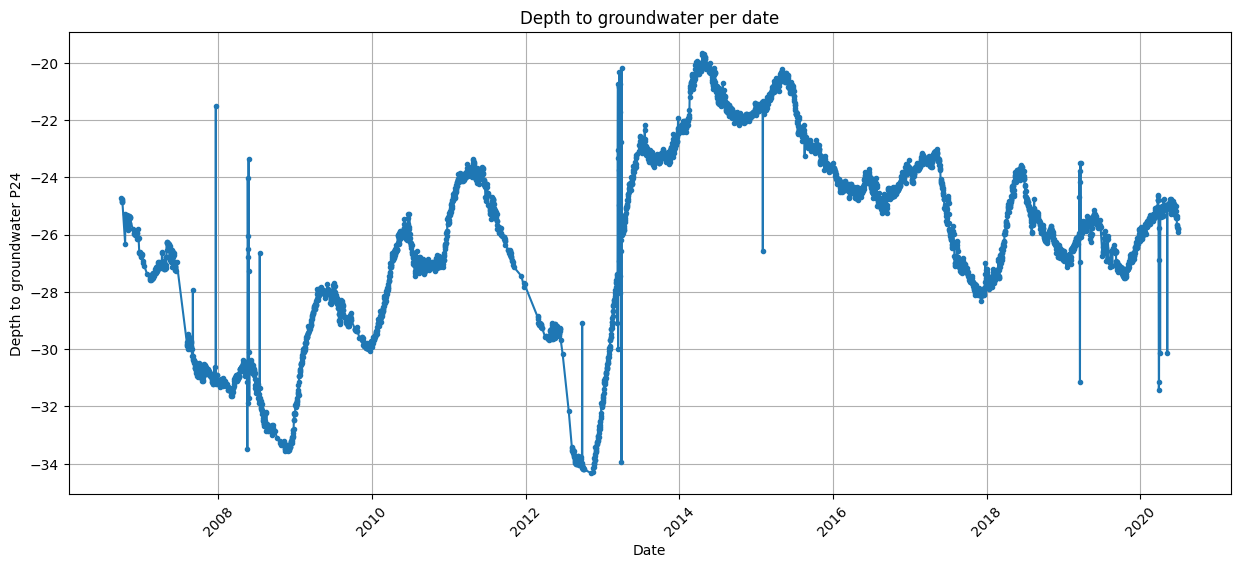

In [19]:
plt.figure(figsize=(15,6))
plt.plot(ap.index, ap['Depth_to_Groundwater_P24'],marker='.')
plt.title("Depth to groundwater per date")
plt.xlabel('Date')
plt.ylabel('Depth to groundwater P24')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Feature Engineering

### Instructions:
  
- **Shift Method**: Use the `shift` method to create a new column `Prev_Depth_to_Groundwater_P24`, which represents the previous day's groundwater depth. This helps capture the effect of past values on current observations.

- **Date Features**: Extract meaningful time-based features from the `Date` column to enhance the model's ability to detect temporal patterns. These features include:
  - **Day of the week**: To capture weekly seasonality.
  - **Month**: To capture monthly trends.
  - **Day of the year**: Useful for modeling yearly seasonality.
  - **IsWeekend**: A binary feature that distinguishes between weekdays and weekends.
  - **Difference between Depth_to_Groundwater_P24**: Calculate the difference between consecutive values in the `Depth_to_Groundwater_P24` column to highlight short-term changes in groundwater depth.

In [20]:
ap['Prev_Depth_to_Groundwater_P24']=ap['Depth_to_Groundwater_P24'].shift(1)

In [21]:
ap['day_of_week']=ap.index.dayofweek
ap['month']=ap.index.month
ap['day_of_year']=ap.index.dayofyear
ap['is_weekend']=ap.index.dayofweek>4
ap['diff_depth']=ap['Depth_to_Groundwater_P24'].diff()

In [22]:
ap.head()

,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano,Prev_Depth_to_Groundwater_P24,day_of_week,month,day_of_year,is_weekend,diff_depth
Date,,,,,,,,,,,,,
2006-09-27,1.693156,-24.73,-24.12,14.846951,13.471451,-29281.824,2.409028,NaN,2,9,270,False,NaN
2006-09-28,1.693156,-24.77,-24.18,14.846951,13.471451,-29245.536,2.409028,-24.73,3,9,271,False,-0.04
2006-09-29,1.693156,-24.80,-24.22,14.846951,13.471451,-29355.264,2.409028,-24.77,4,9,272,False,-0.03
2006-09-30,1.693156,-24.85,-24.28,14.846951,13.471451,-30174.336,2.409028,-24.80,5,9,273,True,-0.05
2006-10-01,1.693156,-24.82,-24.27,14.846951,13.471451,-28530.144,2.409028,-24.85,6,10,274,True,0.03


## Train-Test Split

Split the dataset into training and testing sets.

**Instructions:**
- Ensure the split maintains the time order of the data.
- Decide on an appropriate ratio for splitting the data.

In [23]:
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    # Convert the DataFrame to a NumPy array for easier slicing
    data_array = dataset.values
    for i in range(len(data_array) - time_step - 1):
        a = data_array[i:(i + time_step), 0] # Select the first column for features
        X.append(a)
        Y.append(data_array[i + time_step, 0]) # Select the first column for target
    return np.array(X), np.array(Y)
time_step=30
X, Y = create_dataset(ap[['Depth_to_Groundwater_P24']], time_step)

In [24]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Feature Scaling

Apply feature scaling to the data if needed.

**Instructions:**
- Use a scaling method such as MinMaxScaler or StandardScaler.
- Ensure scaling is applied correctly to both training and testing data.

In [25]:
# Reshape X_train and X_test to be 2D before scaling
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Now scale the 2D data
mimx = MinMaxScaler()
X_train_scaled = mimx.fit_transform(X_train_2d)
X_test_scaled = mimx.transform(X_test_2d)

# If you need the 3D shape for your model, reshape back after scaling
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

## Models Selection

Choose two models for time series forecasting.

**Instructions:**
- Select two models such as ARIMA, SARIMA, RNN, LSTM, or GRU.
- Train these models and then compare their performance.

In [26]:
model = Sequential()


model.add(SimpleRNN(units=60, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))         # Adding dropout to prevent overfitting


model.add(SimpleRNN(units=60, return_sequences=True))
model.add(Dropout(0.2))


model.add(SimpleRNN(units=60))
model.add(Dropout(0.2))


model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 30, 60)              │           3,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 30, 60)              │           7,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 60)                  │           7,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              61 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,301 (71.49 KB)

 Trainable params: 18,301 (71.49 KB)

 Non-trainable params: 0 (0.00 B)

### Model 1 Training

Train your first model on the training dataset.

**Instructions:**
- Fit the first model to the training data.
- Ensure to monitor the training process.

In [35]:
model.fit(X_train, Y_train, epochs=100, batch_size=64, validation_data=(X_test, Y_test))

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2094 - val_loss: 0.2870
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3047 - val_loss: 0.2277
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1898 - val_loss: 0.2238
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.2578 - val_loss: 0.2576
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.2322 - val_loss: 0.2196
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2354 - val_loss: 0.2139
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2622 - val_loss: 0.2793
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2111 - val_loss: 0.2279
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.3304 - val_loss: 0.2180
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.2479 - val_loss: 0.2400
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1701 - val_loss: 0.2546
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step

### Make 1 Predictions

Generate predictions on the test dataset.

### Instructions:
- Use the trained model to make predictions on the test data.
- Store the predictions for further analysis.

In [36]:
predictions = model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


### Model 1 Evaluation

Evaluate the performance of your first model on the test dataset.

**Instructions:**
- Calculate evaluation metrics such as MAE, MSE, RMSE, or MAPE.
- Plot the predicted vs actual values for the test set.
- Plot the loss and the validation loss.

In [37]:
print(math.sqrt(mean_squared_error(Y_test,predictions)))

0.4554423701164641


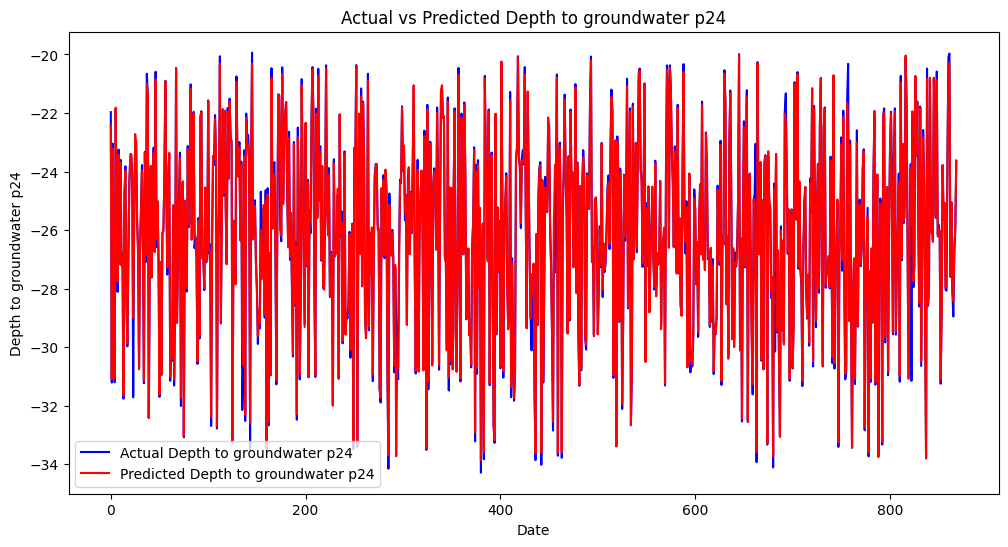

In [38]:

plt.figure(figsize=(12,6))
plt.plot(Y_test, label='Actual Depth to groundwater p24', color='blue')
plt.plot(predictions, label='Predicted Depth to groundwater p24', color='red')
plt.title('Actual vs Predicted Depth to groundwater p24')
plt.xlabel('Date')
plt.ylabel('Depth to groundwater p24')
plt.legend()
plt.show()

### Model 2 Training

Train your second model on the training dataset.

**Instructions:**
- Fit the second model to the training data.
- Ensure to monitor the training process.

In [31]:
model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    GRU(units=50, return_sequences=False),
    Dense(units=25),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_data=(X_test, Y_test))

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 268.5711 - val_loss: 11.0164
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 10.2741 - val_loss: 10.4749
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 7.6646 - val_loss: 0.5920
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.4907 - val_loss: 0.3136
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.3779 - val_loss: 0.2573
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.2560 - val_loss: 0.2799
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.3217 - val_loss: 0.2584
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.3101 - val_loss: 0.2310
Epoch 9/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.3099 - val_loss: 0.2539
Epoch 10/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.2871 - val_loss: 0.2310


### Make 2 Predictions

Generate predictions on the test dataset.

### Instructions:
- Use the trained model to make predictions on the test data.
- Store the predictions for further analysis.

In [32]:
predicted_GRU= model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


### Model 2 Evaluation

Evaluate the performance of your second model on the test dataset.

**Instructions:**
- Calculate evaluation metrics such as MAE, MSE, RMSE, or MAPE.
- Plot the predicted vs actual values for the test set.
- Plot the loss and the validation loss.

In [33]:
print(math.sqrt(mean_squared_error(Y_test,predicted_GRU)))

0.48065634544317376


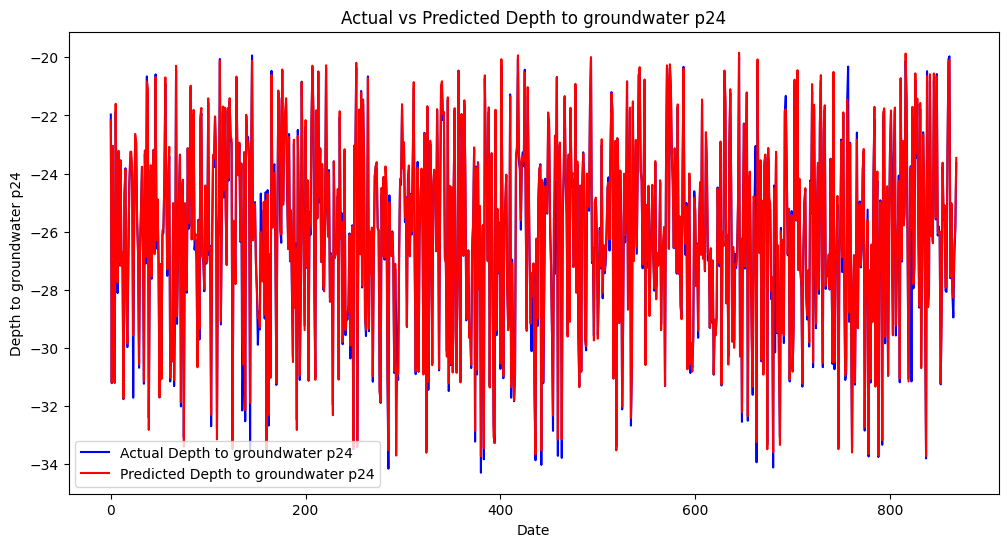

In [34]:
plt.figure(figsize=(12,6))
plt.plot(Y_test, label='Actual Depth to groundwater p24', color='blue')
plt.plot(predicted_GRU, label='Predicted Depth to groundwater p24', color='red')
plt.title('Actual vs Predicted Depth to groundwater p24')
plt.xlabel('Date')
plt.ylabel('Depth to groundwater p24')
plt.legend()
plt.show()

## Conclusion and Interpretation

Write your conclusions based on the model's performance and the forecast.

**Instructions:**
- Interpret the results and discuss the effectiveness of your model.
- Suggest potential improvements.